# 07 · Drift quantification and single-threshold baseline

```
04_feature_engineering  ──►  data/processed/features_train.parquet
06_thin_file_signal         (why thin-file applicants are harder to score)
        ▼
07_drift_and_baseline   ◄── this notebook
```

**Why this notebook exists.** Notebook 04 shows thin-file default risk falling over `WEEK_NUM`
while established risk stays flat, but never puts a number on it. Notebook 06 shows thin-file
applicants are the same people with less information. This notebook turns both into the two
figures the project needs.

**Two outputs:**

1. **Drift:** how many percentage points the thin-file vs. established default-rate gap narrows
   from the early weeks to the late weeks. This justifies a separate thin-file cutoff in November.
2. **Baseline:** apply one cutoff to everyone, then measure approval rates by segment *among
   applicants who actually repaid*. This is the inclusion gap the Inclusive Profit Score has to beat.

The model is fitted on training weeks (`WEEK_NUM < 80`) only. Weeks 80–91 are used for evaluation.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"

# Same cutoff as notebooks 04/05/06: weeks 80-91 are out-of-time validation
VALID_START_WEEK = 80

df = pd.read_parquet(PROCESSED / "features_train.parquet")
df["segment"] = np.where(df["thin_file"] == 1, "thin_file", "established")

print(df.shape)
print(df["segment"].value_counts(normalize=True))
print("WEEK_NUM range:", df["WEEK_NUM"].min(), "to", df["WEEK_NUM"].max())

(1000000, 62)
segment
established    0.700179
thin_file      0.299821
Name: proportion, dtype: float64
WEEK_NUM range: 0 to 91


## 1. Default rate by week

segment
established    0.700179
thin_file      0.299821
Name: proportion, dtype: float64
WEEK_NUM range: 0 to 91


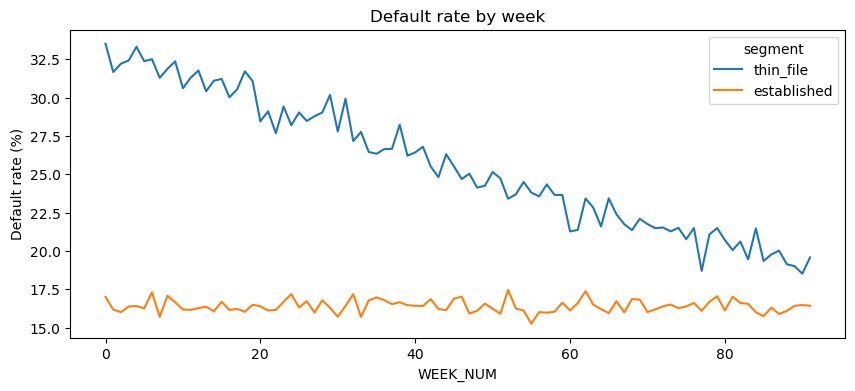

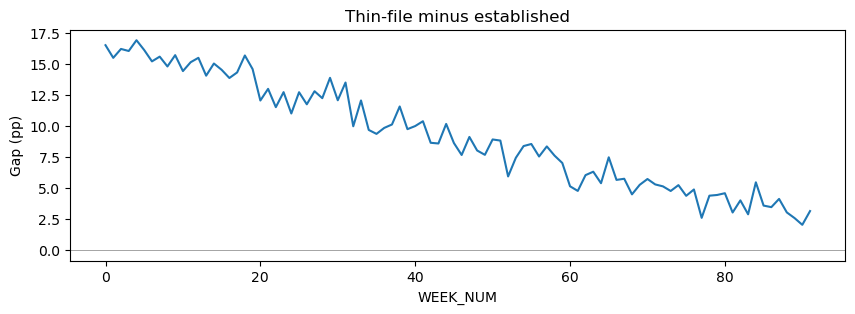

In [20]:
import numpy as np
import matplotlib.pyplot as plt

df["segment"] = np.where(df["thin_file"] == 1, "thin_file", "established")
print(df["segment"].value_counts(normalize=True))
print("WEEK_NUM range:", df["WEEK_NUM"].min(), "to", df["WEEK_NUM"].max())

weekly = df.groupby(["WEEK_NUM", "segment"])["target"].mean().unstack()
weekly["gap_pp"] = (weekly["thin_file"] - weekly["established"]) * 100

weekly[["thin_file", "established"]].mul(100).plot(figsize=(10, 4), ylabel="Default rate (%)", title="Default rate by week")
plt.show()
weekly["gap_pp"].plot(figsize=(10, 3), ylabel="Gap (pp)", title="Thin-file minus established")
plt.axhline(0, color="grey", lw=0.5)
plt.show()

## 2. Quantify the drift

Compares the first quarter of weeks to the last quarter. The 95% confidence interval uses the
standard error of a difference in proportions. A linear trend across all weeks is included as a
second check. This section uses all weeks because it only describes what happened; nothing is fitted.

In [24]:
weeks = np.sort(df["WEEK_NUM"].unique())
n = len(weeks) // 4
early_weeks, late_weeks = weeks[:n], weeks[-n:]

def gap_stats(sub):
    r = sub.groupby("segment")["target"].agg(["mean", "count"])
    gap = r.loc["thin_file", "mean"] - r.loc["established", "mean"]
    se = np.sqrt((r["mean"] * (1 - r["mean"]) / r["count"]).sum())
    return r, gap * 100, se * 100

r_e, gap_e, se_e = gap_stats(df[df["WEEK_NUM"].isin(early_weeks)])
r_l, gap_l, se_l = gap_stats(df[df["WEEK_NUM"].isin(late_weeks)])
narrow = gap_e - gap_l
se = np.sqrt(se_e**2 + se_l**2)

print(f"Early weeks {early_weeks.min()}–{early_weeks.max()}: gap = {gap_e:.2f} pp")
print(r_e, "\n")
print(f"Late weeks {late_weeks.min()}–{late_weeks.max()}: gap = {gap_l:.2f} pp")
print(r_l, "\n")
print(f"Gap narrows by {narrow:.2f} pp (95% CI: {narrow - 1.96*se:.2f} to {narrow + 1.96*se:.2f})")

w = weekly["gap_pp"].dropna()
slope, _ = np.polyfit(w.index, w.values, 1)
print(f"Linear trend: {slope:.3f} pp per week ≈ {slope * (weeks.max() - weeks.min()):.2f} pp over the full window")

Early weeks 0–22: gap = 14.88 pp
                 mean   count
segment                      
established  0.163660  175174
thin_file    0.312416   74804 

Late weeks 69–91: gap = 4.10 pp
                 mean   count
segment                      
established  0.163823  175018
thin_file    0.204777   74940 

Gap narrows by 10.78 pp (95% CI: 10.28 to 11.28)
Linear trend: -0.157 pp per week ≈ -14.30 pp over the full window


## 3. Baseline default model

Gradient-boosted model trained on weeks 0–79 and evaluated on weeks 80–91 (same split as
notebooks 04–06). `thin_file` is excluded as a feature so everyone is scored by the same rules,
as a standard lender would.

In [25]:
X = df.drop(columns=["case_id", "date_decision", "WEEK_NUM", "target", "thin_file", "segment"])
X = X.select_dtypes(exclude=["datetime", "datetimetz"])
obj_cols = X.select_dtypes(include=["object", "string"]).columns
X = X.drop(columns=[c for c in obj_cols if X[c].nunique() > 250])
for c in X.select_dtypes(include=["object", "string"]).columns:
    X[c] = X[c].astype("category")
y = df["target"]

# Time-based split: train on the past, test on the most recent weeks
train_mask = (df["WEEK_NUM"] < VALID_START_WEEK).values
X_tr, X_te = X[train_mask], X[~train_mask]
y_tr, y_te = y[train_mask], y[~train_mask]
seg_te = df.loc[~train_mask, "segment"]

print(f"Train: weeks 0–{VALID_START_WEEK - 1}, {len(X_tr):,} applicants")
print(f"Test:  weeks {VALID_START_WEEK}–{df['WEEK_NUM'].max()}, {len(X_te):,} applicants\n")

model = HistGradientBoostingClassifier(categorical_features="from_dtype", max_iter=300,
                                       learning_rate=0.05, random_state=42)
model.fit(X_tr, y_tr)
p_te = model.predict_proba(X_te)[:, 1]

print(f"AUC overall: {roc_auc_score(y_te, p_te):.3f}")
for s in ["established", "thin_file"]:
    m = (seg_te == s).values
    print(f"AUC {s}: {roc_auc_score(y_te[m], p_te[m]):.3f}")

Train: weeks 0–79, 869,559 applicants
Test:  weeks 80–91, 130,441 applicants

AUC overall: 0.768
AUC established: 0.795
AUC thin_file: 0.706


## 4. Single-threshold policy and the inclusion gap

One cutoff applied to everyone at several overall approval rates. The key column is
`inclusion_gap_pp`: established approval rate minus thin-file approval rate, **among applicants
who repaid**.

In [26]:
res = pd.DataFrame({"segment": seg_te.values, "target": y_te.values, "pd": p_te})
repaid = res["target"] == 0

def evaluate(approval_rate):
    cutoff = np.quantile(res["pd"], approval_rate)
    approve = res["pd"] <= cutoff
    out = {"overall_approval": approval_rate, "cutoff_pd": cutoff}
    for s in ["established", "thin_file"]:
        seg = res["segment"] == s
        out[f"{s}_approval"] = approve[seg].mean()
        out[f"{s}_approval_among_repayers"] = approve[seg & repaid].mean()
        out[f"{s}_bad_rate_approved"] = res.loc[seg & approve, "target"].mean()
    out["inclusion_gap_pp"] = (out["established_approval_among_repayers"]
                               - out["thin_file_approval_among_repayers"]) * 100
    return out

baseline = pd.DataFrame([evaluate(a) for a in [0.5, 0.6, 0.7, 0.8, 0.9]]).set_index("overall_approval")
baseline.round(3)

,cutoff_pd,established_approval,established_approval_among_repayers,established_bad_rate_approved,thin_file_approval,thin_file_approval_among_repayers,thin_file_bad_rate_approved,inclusion_gap_pp
overall_approval,,,,,,,,
0.5,0.144,0.597,0.667,0.064,0.273,0.316,0.074,35.158
0.6,0.192,0.696,0.767,0.078,0.374,0.426,0.087,34.077
0.7,0.237,0.766,0.833,0.091,0.545,0.603,0.112,22.925
0.8,0.321,0.847,0.903,0.108,0.690,0.748,0.131,15.516
0.9,0.422,0.918,0.957,0.128,0.857,0.898,0.160,5.894


**2. A single threshold shuts out creditworthy thin-file applicants.** At 70% overall approval
(model trained on weeks 0–79, evaluated on weeks 80–91), 83.3% of established repayers are
approved versus 60.3% of thin-file repayers: an inclusion gap of **22.9 pp**. The gap ranges from
35.2 pp at 50% approval to 5.9 pp at 90%, but loosening the cutoff raises the thin-file bad rate
among approved applicants from 7.4% to 16.0%. This is the benchmark the Inclusive Profit Score
must beat.

**3. The model sees thin-file applicants less clearly.** Out-of-time AUC is 0.795 for established
vs 0.706 for thin-file, consistent with notebook 06's finding that 22 of 51 features are dead for
this segment.

## 5. Save for the team

In [27]:
OUT = ROOT / "data" / "processed"

baseline.round(4).to_csv(OUT / "baseline_single_threshold.csv")

drift_summary = pd.DataFrame({
    "early_weeks": [f"{early_weeks.min()}-{early_weeks.max()}"],
    "late_weeks": [f"{late_weeks.min()}-{late_weeks.max()}"],
    "gap_early_pp": [round(gap_e, 2)],
    "gap_late_pp": [round(gap_l, 2)],
    "gap_narrowing_pp": [round(narrow, 2)],
    "ci_low_pp": [round(narrow - 1.96 * se, 2)],
    "ci_high_pp": [round(narrow + 1.96 * se, 2)],
    "trend_pp_per_week": [round(slope, 4)],
})
drift_summary.to_csv(OUT / "drift_summary.csv", index=False)

print("saved baseline_single_threshold.csv  (inclusion gap at 5 approval rates)")
print("saved drift_summary.csv              (gap narrowing + 95% CI)")

saved baseline_single_threshold.csv  (inclusion gap at 5 approval rates)
saved drift_summary.csv              (gap narrowing + 95% CI)
